In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("C:\\Datasets_ml\\placement-dataset.csv")
df

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0
...,...,...,...,...
95,Chicago,4.3,200.0,0
96,New York,4.4,42.0,0
97,Los Angeles,6.7,182.0,1
98,Chicago,6.3,103.0,1


In [3]:
# steps  
    # 0. preprocess + EDA + feature selection
    # 1. Scaler te values
    # 2. SCale test split
    # 3. Train test split 
    # 4. Train the model
    # 5. Evalute the model/model selection
    # 6. Deploy the model
    

In [4]:
df = df.iloc[:,1:]
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,NaN,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       92 non-null     float64
 1   iq         96 non-null     float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [6]:
df.isnull().sum()

cgpa         8
iq           4
placement    0
dtype: int64

In [7]:

df = df.dropna()

In [8]:
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

In [9]:
import matplotlib.pyplot as plt

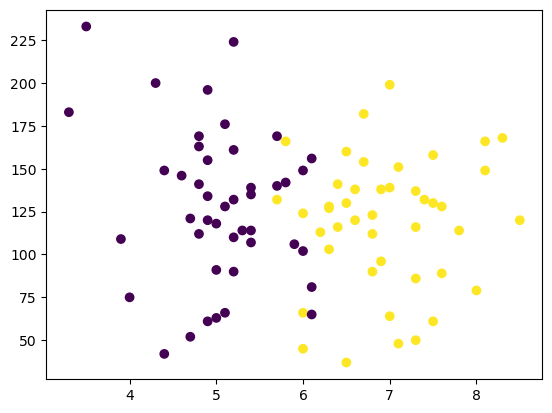

In [10]:
plt.scatter(df['cgpa'],df['iq'],c = df['placement'])

In [11]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
3,7.4,132.0
4,5.8,142.0
5,7.1,48.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y.shape

(88,)

In [14]:
y

0     1
1     0
3     1
4     0
5     1
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 88, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.2)

In [17]:
X_train

,cgpa,iq
87,5.7,132.0
10,6.0,45.0
66,6.9,96.0
11,6.9,138.0
44,7.5,61.0
...,...,...
17,3.3,183.0
75,4.8,169.0
8,6.1,156.0
34,4.8,163.0


In [18]:
X_test

,cgpa,iq
40,4.9,134.0
51,4.8,141.0
67,5.0,118.0
78,6.1,81.0
50,3.5,233.0
84,5.7,169.0
97,6.7,182.0
21,7.1,151.0
55,7.8,114.0
38,6.5,160.0


In [19]:
y_train

87    1
10    1
66    1
11    1
44    1
     ..
17    0
75    0
8     0
34    0
36    0
Name: placement, Length: 70, dtype: int64

In [20]:
y_test

40    0
51    0
67    0
78    0
50    0
84    0
97    1
21    1
55    1
38    1
42    1
56    0
7     0
57    1
72    1
73    0
88    0
91    1
Name: placement, dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
X_train = scaler.fit_transform(X_train)

In [24]:
X_train

array([[-0.27105081,  0.24444551],
       [-0.00874357, -1.91305179],
       [ 0.77817813, -0.648312  ],
       [ 0.77817813,  0.39323842],
       [ 1.3027926 , -1.51627068],
       [ 0.3409994 , -0.15233561],
       [-1.232844  ,  0.59162898],
       [-0.70822953, -0.30112852],
       [-0.88310102, -0.77230609],
       [ 1.82740706,  0.66602544],
       [ 1.21535685,  0.24444551],
       [-0.97053677,  1.83156996],
       [-0.97053677, -0.05314033],
       [-1.40771549, -1.98744825],
       [ 2.00227855,  1.13720301],
       [-1.14540826, -1.73946006],
       [-1.84489421, -0.32592734],
       [ 0.86561387,  0.41803724],
       [-0.79566528,  1.33559357],
       [-1.49515123,  1.93076523],
       [-1.75745847, -1.16908721],
       [ 1.12792111, -0.89630019],
       [ 0.69074238, -0.25153088],
       [ 0.69074238, -0.79710491],
       [-0.62079379, -0.20193324],
       [ 0.69074238,  0.02125613],
       [ 2.17715004, -0.05314033],
       [-0.70822953,  0.24444551],
       [-0.53335804,

In [25]:
X_test = scaler.fit_transform(X_test)

In [26]:
X_test

array([[-0.87580888,  0.12247092],
       [-0.95791597,  0.27993352],
       [-0.7937018 , -0.23744361],
       [ 0.10947611, -1.06974597],
       [-2.02530804,  2.34944207],
       [-0.21895222,  0.90978395],
       [ 0.60211861,  1.20221451],
       [ 0.93054694,  0.50488011],
       [ 1.50529652, -0.32742225],
       [ 0.43790444,  0.70733203],
       [ 1.34108235, -0.8897887 ],
       [ 0.10947611, -1.4296605 ],
       [-0.7937018 , -1.47464981],
       [ 0.43790444,  0.03249228],
       [ 1.0947611 , -0.28243293],
       [-0.87580888, -1.51963913],
       [-1.2863443 ,  0.45989079],
       [ 1.25897527,  0.66234271]])

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf = LogisticRegression()

In [29]:
# model training
clf.fit(X_train, y_train)

LogisticRegression()

In [36]:
y_pred = clf.predict(X_test)

In [37]:
y_test

40    0
51    0
67    0
78    0
50    0
84    0
97    1
21    1
55    1
38    1
42    1
56    0
7     0
57    1
72    1
73    0
88    0
91    1
Name: placement, dtype: int64

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(y_test, y_pred)

0.8888888888888888

In [ ]:
!pip install mlxtend


In [ ]:
from mlxtend.plotting import plot_decision_regions

In [ ]:
!pip install mlxtend


In [ ]:
plot_decision_regions(X_train, Y_train ,clf = clf, legend = 2)